# Notebook 2 — Treinamento do Modelo e Estimativa de Performance com NannyML

## Aula 8: Integração e Revisão (Ferramentas e Validação)

### Objetivos

1. Pré-processar dados de referência (encoding + scaling) para treinamento.
2. Treinar o modelo **FraudDetector** (Random Forest) nos dados de referência.
3. Avaliar performance com métricas clássicas (accuracy, precision, recall, F1, ROC AUC).
4. Verificar drift nas features usando **testes KS** integrados ao modelo.
5. Utilizar **NannyML CBPE** para estimar performance nos dados de produção **sem rótulos**.
6. Comparar performance real vs estimada para demonstrar a utilidade do CBPE.

### Conexão com o Documento 04

> *"O NannyML combina técnicas estatísticas e aprendizagem de máquina para estimar*
> *a performance do modelo em produção sem rótulos. Um método central é o*
> *CBPE (Confidence-Based Performance Estimation)."*
> — DOCUMENTO_AULA_8.md, seção 'Performance Drift e Estimativa Sem Rótulo'

### Vídeos Relacionados

- **Vídeo 8.2**: NannyML e estimativa de performance sem ground truth.
- **Vídeo 8.3**: Pipeline integrado end-to-end de detecção e mitigação.

In [1]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Adicionar diretório pai ao path para importar src/
sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    TARGET_COL,
    DataPreprocessor,
)
from src.model import FraudDetector
from src.training import train_model, cross_validate_model
from src.evaluation import (
    calculate_metrics,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
)
from src.utils import save_model, save_metrics, set_seed

# Configurações
set_seed(42)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

%matplotlib inline

## 1. Carregamento e Pré-processamento

Conforme o pipeline do Documento 04, o pré-processamento separa dados em
referência (baseline) e produção, aplicando encoding categórico e scaling numérico.
O scaler é ajustado **apenas nos dados de referência** (fit), e depois aplicado
nos dados de produção (transform), garantindo consistência.

In [2]:
# Carregar dados
preprocessor = DataPreprocessor()
df = preprocessor.load_data("../data/raw/dataset.csv")

# Separar por período
df_ref = df[df["periodo"] == "referencia"].copy()
df_prod = df[df["periodo"] == "producao"].copy()

# Limpar dados
df_ref_clean = preprocessor.clean_data(df_ref)

# Preparar features — fit no referência
df_ref_prepared = preprocessor.prepare_features(df_ref_clean, fit=True)

# Split treino/teste (dentro do período de referência)
X_train, X_test, y_train, y_test = preprocessor.split_data(
    df_ref_prepared, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Taxa de fraude — treino: {y_train.mean():.2%} | teste: {y_test.mean():.2%}")

Treino: (4000, 13) | Teste: (1000, 13)
Taxa de fraude — treino: 5.00% | teste: 5.00%


## 2. Validação Cruzada

Antes de treinar o modelo final, realizamos **validação cruzada estratificada**
para obter estimativa robusta de performance, conforme boas práticas
discutidas no Documento 04.

In [3]:
# Validação cruzada estratificada (5-fold)
cv_results = cross_validate_model(
    X_train, y_train, n_splits=5, scoring="roc_auc", random_state=42
)

print("Validação Cruzada (5-fold, ROC AUC):")
for i, score in enumerate(cv_results["scores"], 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Média: {cv_results['mean']:.4f} ± {cv_results['std']:.4f}")

Validação Cruzada (5-fold, ROC AUC):
  Fold 1: 0.9912
  Fold 2: 0.9974
  Fold 3: 0.9842
  Fold 4: 0.9777
  Fold 5: 0.9775
  Média: 0.9856 ± 0.0078


## 3. Treinamento do Modelo de Fraude

Conforme o Documento 04 (seção 'Pipeline Integrado End-to-End'), o treinamento
deve armazenar distribuições de referência para posterior detecção de drift.

> *"Esse paradigma reflete uma mudança de cultura em ML: não basta treinar e*
> *implantar modelos; é preciso monitorá-los continuamente."*
> — Sculley et al. (NIPS 2015), citado no Documento 04.

In [4]:
# Treinar modelo — armazena P_ref(X) internamente
detector = train_model(
    X_train, y_train,
    n_estimators=100,
    max_depth=10,
    random_state=42,
    store_reference=True,
    save_path="../outputs/models/fraud_detector_v1.pkl",
)

print(f"Modelo treinado: {type(detector).__name__}")
print(f"Features: {detector.feature_names}")
print(f"Distribuições de referência armazenadas: {len(detector.reference_distributions)}")

Modelo treinado: FraudDetector
Features: ['valor_transacao', 'tempo_conta_cliente', 'num_transacoes_24h', 'valor_medio_historico', 'distancia_localizacao', 'hora_transacao', 'score_risco_dispositivo', 'tentativas_senha', 'is_weekend', 'razao_valor_medio', 'tipo_cartao', 'canal_transacao', 'pais_origem']
Distribuições de referência armazenadas: 13


## 4. Avaliação no Conjunto de Teste (Referência)

Métricas de performance nos dados de teste (dentro do período de referência),
onde esperamos bom desempenho pois não há drift.

In [5]:
# Métricas no conjunto de teste
y_pred_test = detector.predict(X_test)
y_proba_test = detector.predict_proba(X_test)[:, 1]

metrics_ref = calculate_metrics(y_test.values, y_pred_test, y_proba_test)

print("Performance no Teste (Referência — sem drift):")
for name, value in metrics_ref.items():
    print(f"  {name}: {value:.4f}")

# Salvar métricas
save_metrics(metrics_ref, "../outputs/logs/metrics_reference.json")

Performance no Teste (Referência — sem drift):
  accuracy: 0.9660
  precision: 0.7857
  recall: 0.4400
  f1: 0.5641
  roc_auc: 0.9808


'C:\\Personal\\Others\\FIAP\\POSTECH-DATA_DRIFT\\9mlet-data-drift\\08_integracao_e_revisao_ferramentas_e_validacao\\outputs\\logs\\metrics_reference.json'

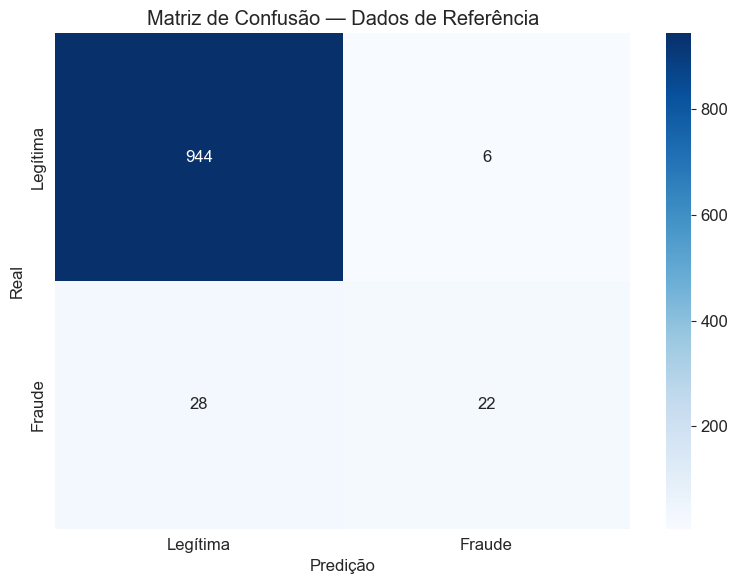

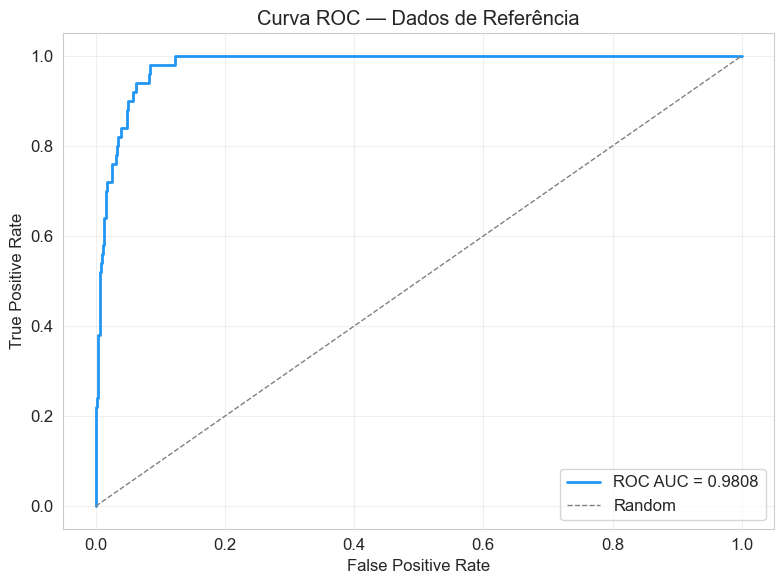

In [6]:
# Visualizações de performance
fig_cm = plot_confusion_matrix(
    y_test.values, y_pred_test,
    title="Matriz de Confusão — Dados de Referência",
    save_path="../outputs/figures/02_confusion_matrix_ref.png",
)
plt.show()

fig_roc = plot_roc_curve(
    y_test.values, y_proba_test,
    title="Curva ROC — Dados de Referência",
    save_path="../outputs/figures/02_roc_curve_ref.png",
)
plt.show()

## 5. Avaliação nos Dados de Produção (Com Drift)

Agora avaliamos o modelo nos dados de produção, onde sabemos que há **drift simulado**.
Esperamos observar degradação de performance, confirmando o impacto do drift.

Conforme o Documento 04:
> *"Quase todos os classificadores sofrem reduções de acurácia sob mudanças*
> *significativas nos dados de entrada."*
> — Rabanser et al. (NeurIPS 2019)

In [7]:
# Preparar dados de produção (transform com scaler do referência)
df_prod_clean = preprocessor.clean_data(df_prod)
df_prod_prepared = preprocessor.prepare_features(df_prod_clean, fit=False)

feature_cols = [c for c in NUMERIC_FEATURES + CATEGORICAL_FEATURES if c in df_prod_prepared.columns]
X_prod = df_prod_prepared[feature_cols]
y_prod = df_prod_prepared[TARGET_COL]

# Predições na produção
y_pred_prod = detector.predict(X_prod)
y_proba_prod = detector.predict_proba(X_prod)[:, 1]

metrics_prod = calculate_metrics(y_prod.values, y_pred_prod, y_proba_prod)

print("Performance na Produção (COM drift):")
for name, value in metrics_prod.items():
    print(f"  {name}: {value:.4f}")

# Comparação
print("\n--- Comparação Referência vs Produção ---")
for name in metrics_ref:
    delta = metrics_prod[name] - metrics_ref[name]
    arrow = "↓" if delta < 0 else "↑"
    print(f"  {name}: {metrics_ref[name]:.4f} → {metrics_prod[name]:.4f} ({arrow} {abs(delta):.4f})")

save_metrics(metrics_prod, "../outputs/logs/metrics_production.json")

Performance na Produção (COM drift):
  accuracy: 0.8286
  precision: 0.2189
  recall: 0.4450
  f1: 0.2935
  roc_auc: 0.8103

--- Comparação Referência vs Produção ---
  accuracy: 0.9660 → 0.8286 (↓ 0.1374)
  precision: 0.7857 → 0.2189 (↓ 0.5668)
  recall: 0.4400 → 0.4450 (↑ 0.0050)
  f1: 0.5641 → 0.2935 (↓ 0.2706)
  roc_auc: 0.9808 → 0.8103 (↓ 0.1705)


'C:\\Personal\\Others\\FIAP\\POSTECH-DATA_DRIFT\\9mlet-data-drift\\08_integracao_e_revisao_ferramentas_e_validacao\\outputs\\logs\\metrics_production.json'

## 6. Detecção de Drift Integrada ao Modelo

O `FraudDetector` inclui verificação de drift via teste KS, conforme a
abordagem integrada discutida no Documento 04. Vamos verificar quais
features apresentam drift significativo nos dados de produção.

In [8]:
# Verificar drift integrado ao modelo
drift_results = detector.check_drift(X_prod)

print("Resultado do check_drift (teste KS por feature):")
print(f"{'Feature':<30} {'KS Stat':>10} {'p-value':>12} {'Drift?':>8}")
print("-" * 64)
for feat, info in sorted(drift_results.items(), key=lambda x: x[1]["p_value"]):
    drift_flag = "✗ SIM" if info["drift_detected"] else "  não"
    print(f"{feat:<30} {info['ks_statistic']:>10.4f} {info['p_value']:>12.2e} {drift_flag:>8}")

n_drifted = sum(1 for v in drift_results.values() if v["drift_detected"])
print(f"\nTotal de features com drift: {n_drifted}/{len(drift_results)}")

Resultado do check_drift (teste KS por feature):
Feature                           KS Stat      p-value   Drift?
----------------------------------------------------------------
score_risco_dispositivo            0.2698    8.31e-143    ✗ SIM
distancia_localizacao              0.2511    1.67e-123    ✗ SIM
num_transacoes_24h                 0.2148     3.10e-90    ✗ SIM
valor_transacao                    0.2125     2.62e-88    ✗ SIM
valor_medio_historico              0.1534     4.59e-46    ✗ SIM
tempo_conta_cliente                0.1448     4.47e-41    ✗ SIM
pais_origem                        0.1244     2.09e-30    ✗ SIM
canal_transacao                    0.1057     4.65e-22    ✗ SIM
hora_transacao                     0.0945     1.03e-17    ✗ SIM
tipo_cartao                        0.0901     4.02e-16    ✗ SIM
tentativas_senha                   0.0879     2.21e-15    ✗ SIM
razao_valor_medio                  0.0857     1.21e-14    ✗ SIM
is_weekend                         0.0004     1.00e+00

## 7. Estimativa de Performance com NannyML CBPE

Conforme o **Snippet 2** do Hands On do Documento 04:
> *"O NannyML é capaz de estimar métricas de performance sem acesso ao rótulo verdadeiro*
> *imediato, através de métodos como CBPE (Confidence-Based Performance Estimation)."*

Vamos simular o cenário onde **não temos os rótulos de produção** e precisamos
estimar se o modelo ainda está funcionando adequadamente.

In [9]:
# Estimativa de performance com NannyML CBPE
# Implementa conceitos do Snippet 2 do Hands On do Documento 04
try:
    import nannyml as nml

    # Preparar dados para NannyML — precisa de coluna de predição e proba
    ref_nml = X_test.copy()
    ref_nml["fraude_predita"] = y_pred_test
    ref_nml["score_fraude"] = y_proba_test
    ref_nml["fraude_real"] = y_test.values

    prod_nml = X_prod.copy()
    prod_nml["fraude_predita"] = y_pred_prod
    prod_nml["score_fraude"] = y_proba_prod
    # Sem rótulos reais na produção!

    # Inicializar estimador CBPE
    cbpe = nml.CBPE(
        y_pred_proba="score_fraude",
        y_pred="fraude_predita",
        y_true="fraude_real",
        problem_type="classification_binary",
        metrics=["roc_auc", "accuracy"],
        chunk_size=200,
    )

    # Ajustar com dados de referência (com rótulos)
    cbpe = cbpe.fit(ref_nml)

    # Estimar performance na produção (SEM rótulos)
    estimated = cbpe.estimate(prod_nml)
    
    # Visualizar resultados
    fig = estimated.plot()
    plt.savefig("../outputs/figures/02_nannyml_cbpe.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("NannyML CBPE — Performance estimada na produção:")
    results_df = estimated.to_df()
    display(results_df.head(10))

except ImportError:
    print("NannyML não instalado. Instale com: pip install nannyml")
    print("\nSimulação manual do conceito CBPE:")
    print(f"  AUC estimada (baseada em scores): ~{y_proba_prod.mean():.4f}")
    print(f"  AUC real (com rótulos): {metrics_prod.get('roc_auc', 'N/A')}")
    print("  → Em produção real, não teríamos acesso aos rótulos!")

except Exception as e:
    print(f"Erro ao executar NannyML: {e}")
    print("Continuando com análise manual.")

c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\.venv\Lib\site-packages\nannyml\chunk.py:181: UserWarning: The resulting number of chunks is too low. Please consider splitting your data in a different way or continue at your own risk.
  warnings.warn(
c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\.venv\Lib\site-packages\nannyml\chunk.py:181: UserWarning: The resulting number of chunks is too low. Please consider splitting your data in a different way or continue at your own risk.
  warnings.warn(
c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\.venv\Lib\site-packages\nannyml\chunk.py:181: UserWarning: The resulting number of chunks is too low. Please consider splitting your data in a different way or continue at your own risk.
  warnings.warn(


<Figure size 1200x600 with 0 Axes>

NannyML CBPE — Performance estimada na produção:


chunk                                                                   \
         key chunk_index start_index end_index start_date end_date     period   
0    [0:199]           0           9      4994       None     None  reference   
1  [200:399]           1           3      4991       None     None  reference   
2  [400:599]           2         100      4984       None     None  reference   
3  [600:799]           3           5      4993       None     None  reference   
4  [800:999]           4           4      4986       None     None  reference   
5    [0:199]           0        5000      5199       None     None   analysis   
6  [200:399]           1        5200      5399       None     None   analysis   
7  [400:599]           2        5400      5599       None     None   analysis   
8  [600:799]           3        5600      5799       None     None   analysis   
9  [800:999]           4        5800      5999       None     None   analysis   

    roc_auc                           ...                         accuracy  \
      value sampling_error  realized  ... lower_threshold  alert     value   
0  0.979346       0.008187  0.976937  ...        0.941661  False  0.954109   
1  0.982027       0.008187  0.985196  ...        0.941661  False  0.969963   
2  0.984603       0.008187  0.996316  ...        0.941661  False  0.972656   
3  0.984780       0.008187  0.957682  ...        0.941661  False  0.968258   
4  0.982873       0.008187  0.983158  ...        0.941661  False  0.970014   
5  0.942574       0.008187       NaN  ...        0.941661  False  0.857116   
6  0.960592       0.008187       NaN  ...        0.941661  False  0.878585   
7  0.948719       0.008187       NaN  ...        0.941661  False  0.858233   
8  0.941607       0.008187       NaN  ...        0.941661   True  0.881042   
9  0.941771       0.008187       NaN  ...        0.941661  False  0.854556   

                                                                               \
  sampling_error realized upper_confidence_boundary lower_confidence_boundary   
0       0.012815    0.945                  0.992554                  0.915665   
1       0.012815    0.985                  1.000000                  0.931518   
2       0.012815    0.980                  1.000000                  0.934212   
3       0.012815    0.955                  1.000000                  0.929814   
4       0.012815    0.965                  1.000000                  0.931569   
5       0.012815      NaN                  0.895561                  0.818672   
6       0.012815      NaN                  0.917029                  0.840140   
7       0.012815      NaN                  0.896678                  0.819789   
8       0.012815      NaN                  0.919486                  0.842597   
9       0.012815      NaN                  0.893001                  0.816112   

                                          
  upper_threshold lower_threshold  alert  
0               1          0.9211  False  
1               1          0.9211  False  
2               1          0.9211  False  
3               1          0.9211  False  
4               1          0.9211  False  
5               1          0.9211   True  
6               1          0.9211   True  
7               1          0.9211   True  
8               1          0.9211   True  
9               1          0.9211   True  

[10 rows x 23 columns]

## 8. Feature Importances e Impacto do Drift

Vamos analisar quais features são mais importantes para o modelo e cruzar
essa informação com as features que sofreram drift — se uma feature importante
também sofreu drift, o impacto na performance será maior.

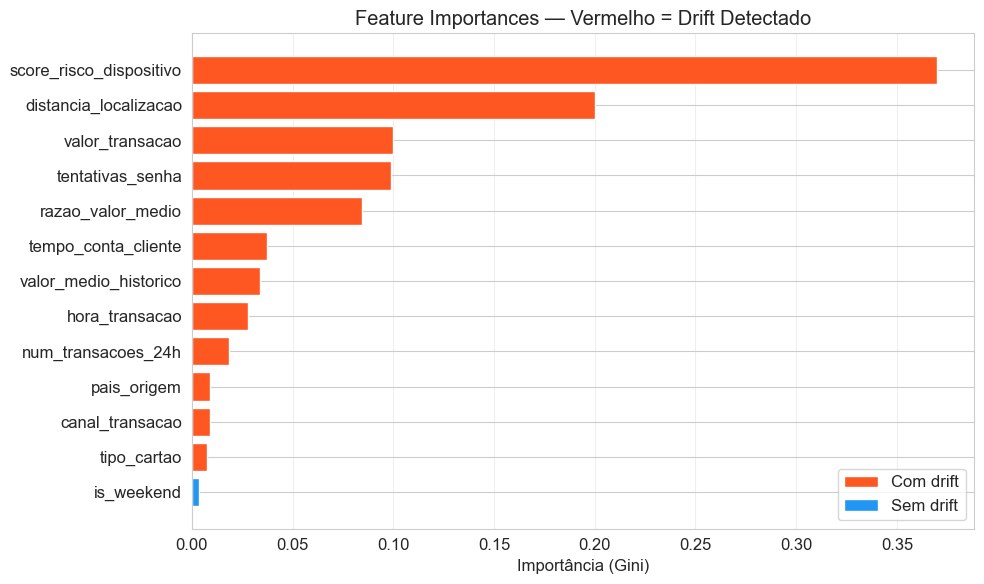

In [10]:
# Feature importances
importances = detector.get_feature_importances()
imp_df = pd.DataFrame({
    "feature": importances.keys(),
    "importance": importances.values(),
}).sort_values("importance", ascending=True)

# Adicionar flag de drift
imp_df["drift"] = imp_df["feature"].apply(
    lambda f: drift_results.get(f, {}).get("drift_detected", False)
)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#FF5722" if d else "#2196F3" for d in imp_df["drift"]]
ax.barh(imp_df["feature"], imp_df["importance"], color=colors)
ax.set_xlabel("Importância (Gini)")
ax.set_title("Feature Importances — Vermelho = Drift Detectado")
ax.grid(True, alpha=0.3, axis="x")

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FF5722", label="Com drift"),
    Patch(facecolor="#2196F3", label="Sem drift"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("../outputs/figures/02_feature_importance_drift.png", dpi=150, bbox_inches="tight")
plt.show()

## Resumo e Próximos Passos

### O que aprendemos neste notebook:

1. **Treinamento**: Modelo Random Forest treinado nos dados de referência com armazenamento de P_ref(X).
2. **Degradação de performance**: O drift nos dados de produção causou queda mensurável nas métricas.
3. **Drift integrado**: O `check_drift()` do FraudDetector detectou drift em múltiplas features.
4. **NannyML CBPE**: É possível estimar performance em produção sem rótulos verdadeiros.
5. **Feature importance + drift**: Features importantes com drift causam maior impacto.

### Próximo notebook

No **Notebook 03 (Avaliação)**, vamos:
- Construir um pipeline integrado end-to-end.
- Aplicar **Great Expectations** para validação de dados de entrada.
- Implementar lógica de **re-treino automático** ao detectar drift.
- Gerar relatório consolidado.

---
*Notebook conectado com: DOCUMENTO_AULA_8.md | Vídeos 8.2 e 8.3*